In [7]:
import sys

sys.path.append("../../src/")

from common_imports import *
from scipy.integrate import solve_ivp
from numpy import conj
from numpy import linalg as la


In [5]:
#Load Pauli Matrices
s3,s1,s2 = array([[1,0],[0,-1]],dtype=complex),array([[0, 1],[1,0]],dtype=complex), array([[0,-1j],[1j,0]],dtype=complex)

In [247]:
#Time Dependent g
def g(t,tau):
    return 1 - np.sign(t)*abs(t/tau)**2
#TFIM functions
def a(q,g):
    return g+ cos(q)
def b(q,g):
    return sin(q)
def w(q,g):
    return sqrt(g*g+2*g*cos(q)+1)
def BdG(q,g):
    return -2*(a(q,g)*s3+b(q,g)*s2)

In [248]:
def nq(sol):
    u = sol.y[0]
    v = sol.y[1]
    t = sol.t
    dat=[]
    for ti,ui,vi in zip(t,u,v):
        ug,vg = la.eigh(BdG(q,g(ti,tau)))[1][:,-1]
        S = array([[ui,-conj(vi)],[vi,conj(ui)]],dtype=complex)
        R = array([[ug,-1j*vg],[-1j*vg,ug]],dtype=complex)
        dat.append( (conj(S).T@conj(R).T@sz@R@S)[1,1]+1 )
    return array(dat)/2

In [249]:
#Time Evolution
def BdG_Evolution(t,U,tau,q):
    return -1j*BdG(q,g(t,tau))@U
def BdG_stationary_evolve(t,U,tau,q):
    return -1j*BdG(q,g(tau,tau))@U

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


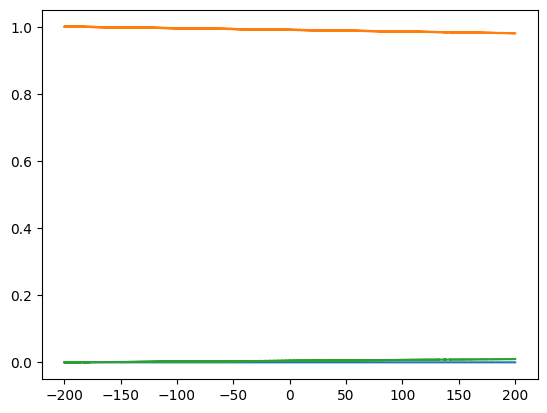

In [250]:
tau = 200
t0 = -tau
q = pi/1000
V0 = la.eigh(BdG(q,g(t0,tau)))[1][:,1]
t_eval = np.linspace(t0, tau, 5000)
sol= solve_ivp(BdG_Evolution,
            [t0,-t0],
            V0,
            args=(tau,q),
            t_eval=t_eval)

u = sol.y[0]
v = sol.y[1]
plot(t_eval,abs(u)**2)
plot(t_eval,abs(v)**2)

n1 = nq(sol)

plot(t_eval,n1)

In [251]:
def BdG_stationary_evolve(t,U,tau,q):
    return -1j*BdG(q,g(tau,tau))@U

V0 = [u[-1],v[-1]]

t_eval2 = np.linspace(tau,2*tau, 1000)
sol= solve_ivp(BdG_Evolution,
            [tau,10*tau],
            V0,
            args=(tau,q),
            t_eval=t_eval2)
u2 = sol.y[0]
v2 = sol.y[1]
n2 = nq(sol)

uf = np.concatenate((u,u2))
vf = np.concatenate((v,v2))
tf = np.concatenate((t_eval,t_eval2))
nf = np.concatenate((n1,n2))

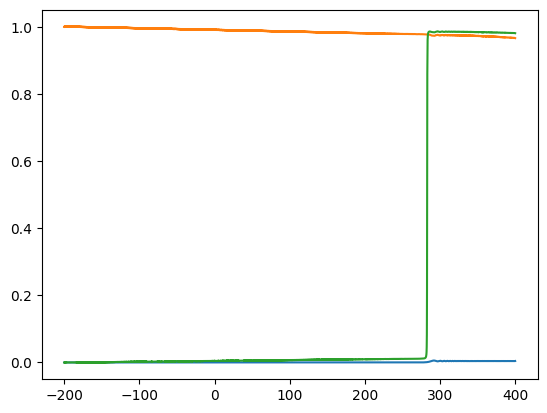

In [252]:
plot(tf,abs(uf)**2)
plot(tf,abs(vf)**2)
plot(tf,abs(nf))

In [253]:
import kibble_zurek as kz

u,v,k=kz.state(4,tau,tau)

In [254]:
def landau_states(tau,L):
    t0 = -tau
    #Initialize Momenta
    n = np.arange(0,L//2)
    k = (2*n+1)*pi/L
    t_eval = np.linspace(t0, tau, 10000)

    #Empty Vectors
    us = []
    vs=  []
    #Time evolve each mode indepdently 
    for q in k:
        V0 = la.eigh(BdG(q,g(t0,tau)))[1][:,1]
        sol= solve_ivp(BdG_Evolution,
                [t0,-t0],
                V0,
                args=(tau,q),
                t_eval=t_eval)

        u = sol.y[0]
        v = sol.y[1]
        us.append(u)
        vs.append(v)
    #Generate a series of states:
    us = array(us)
    vs = array(vs)
    states = []
    for i, ti in enumerate(t_eval):
        state = [us[:,i],vs[:,i],k]
        states.append(state)
    return states,t_eval

      

In [255]:
taus = np.logspace(-2,1.5,10)
landau_defects = []
kz_defects = []
for tau in tqdm(taus):
    print(tau)
    L = 100
    landaustates,t = landau_states(tau,L)
    kzstate = kz.state(L,tau,tau)
    fs = landaustates[-1]
    landau_defects.append(1/2-kz.P_n(8,fs))
    kz_defects.append(1/2-kz.P_n(8,kzstate))


  0%|          | 0/10 [00:00<?, ?it/s]

0.01


 20%|██        | 2/10 [00:00<00:01,  4.14it/s]

0.024484367468222266


 30%|███       | 3/10 [00:00<00:01,  4.36it/s]

...

 80%|████████  | 8/10 [00:01<00:00,  4.37it/s]

12.91549665014884


 90%|█████████ | 9/10 [00:02<00:00,  3.75it/s]

31.622776601683793


100%|██████████| 10/10 [00:02<00:00,  3.56it/s]


[]

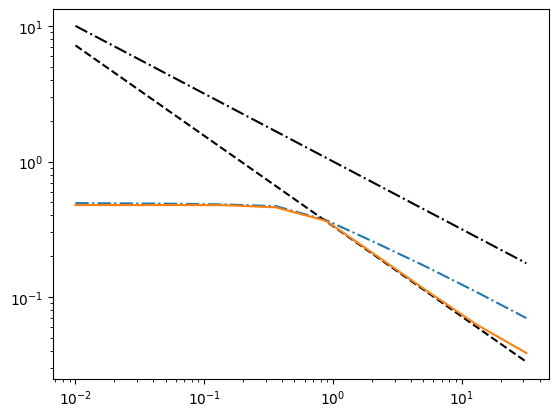

In [265]:
plot(taus,kz_defects,"-.")
plot(taus,taus**(-1/2),"-.k")
plot(taus,taus**(-2/(2+1))/3,"--k")
plot(taus,landau_defects)
loglog()

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


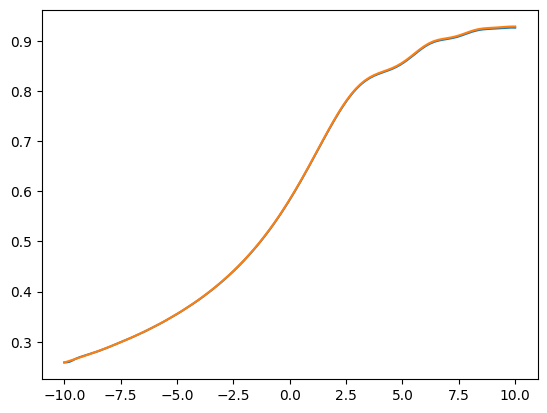

In [227]:
plot(t,xx)
plot(kzt,xxkz)

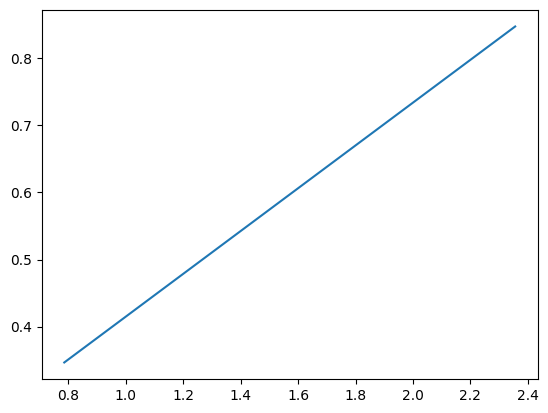

In [181]:
# plot(abs(u[0]))
# plot(abs(u[-1]))

u = array(u)

plot(k,abs(u[:,-1]))
